# Análise Exploratória de Dados

In [1]:
#Importações

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from Apoio.config import DADOS_ORIGINAIS, DADOS_TRATADOS

sns.set_theme(palette="bright")

### Checagens básicas

In [2]:
df = pd.read_csv(DADOS_ORIGINAIS)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.describe(exclude='number')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [6]:
df.nunique()[df.nunique()==1]

EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64

Nota-se que há 3 colunas que possuem apenas 1 valor único. 

Elas não será úteis para o projeto, então podemos excluí-las.

In [7]:
df = df.drop(columns = df.nunique()[df.nunique()==1].index)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

### Checando os valores da coluna alvo ("Attrition")

In [9]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
df['Attrition'].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

### Checando se o dataframe possui colunas com valores nulos e valores duplicados

In [11]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

### Verificando se podemos excluir mais alguma coluna:

In [13]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBalance                4
YearsAtCompany                37
YearsInCurrentRole            19
YearsSince

A coluna "EmployeeNumber" possui 1470 valores únicos (mesmo número de linhas). 

##### Employee Number = Número do Funcionário

Como uma coluna de identificação é irrelevante para o projeto, podemos apagá-la, também.

In [14]:
df = df.drop(["EmployeeNumber"], axis=1)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

### Vamos fazer uma separação das colunas por seus tipos, para auxiliar nas vizualizações:

In [16]:
categoricas_nao_ordenadas = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

categoricas_ordenadas = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                        'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

coluna_alvo = ['Attrition']

colunas_numericas = [
    coluna for coluna in df.columns 
    if coluna not in (categoricas_nao_ordenadas+categoricas_ordenadas+coluna_alvo)
]

In [17]:
colunas_numericas

['Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

### Criando algumas visualizações com as colunas numéricas

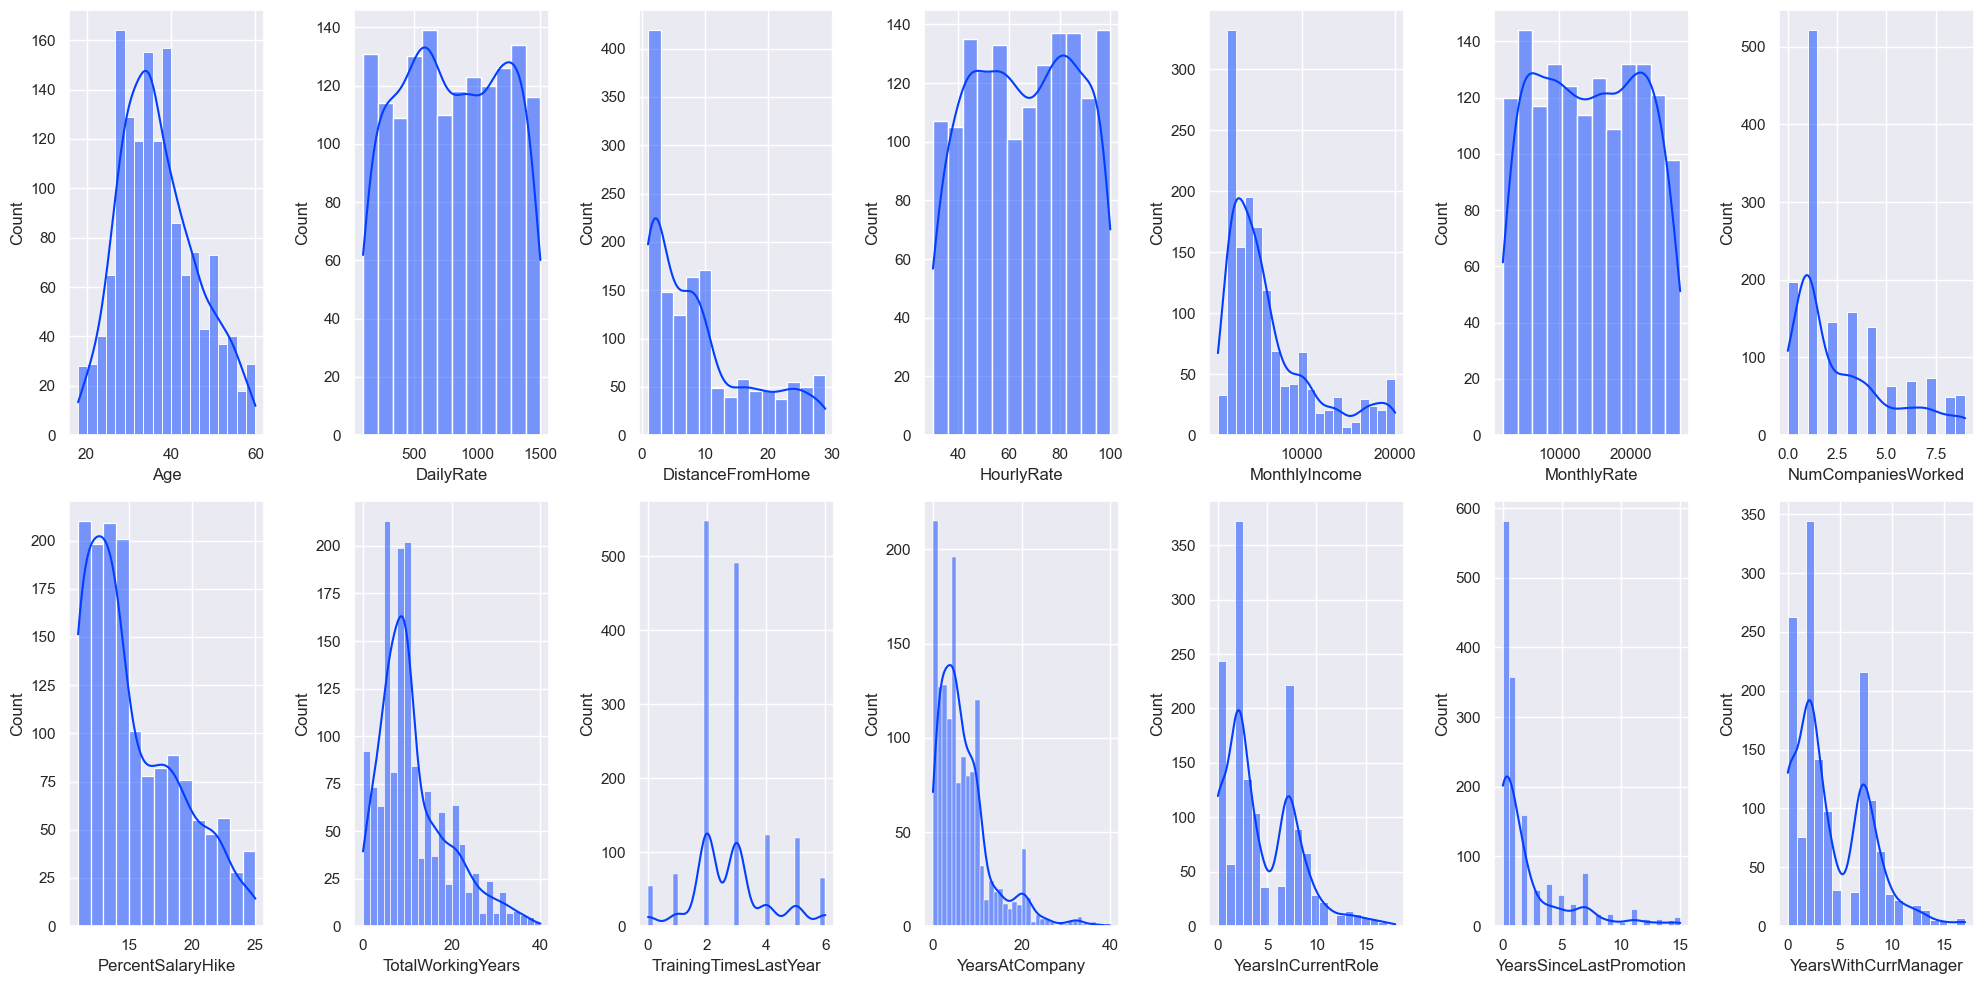

In [18]:
fig, axs = plt.subplots(2, 7, figsize=(20, 10))

for ax, coluna in zip(axs.flatten(), colunas_numericas):
    sns.histplot(data=df, x=coluna, ax=ax, kde=True)

plt.tight_layout()
plt.show()

O que podemos concluir ao observar os histogramas?

- Age: Leve assimetria. Há poucos funcionários muito jovens ou muito velhos.
- DailyRate: Bem distribuído (praticamente uniforme).
- DistanceFromHome: Assimetria positiva (cauda para a direita). A maioria mora perto do local de trabalho.
- HourlyRate: Muito semelhante ao DailyRate.
- MonthlyIncome: Assimetria positiva. Há muitos salários baixos e poucos funcionários possuem altos salários mensais.
- MonthlyRate: Outra distribuição quase uniforme.
- NumCompaniesWorked: Assimetria positiva. Poucos funcionários trabalharam em várias companhias, a maioria trabalhou em apenas 1.
- PercentSalaryHike: Leve assimetria positiva. A porcentagem de percentual do aumento salarial se concentra em valores mais baixos.
- TotalWorkingYears: Assimetria positiva. Muitos funcionários possuem poucos anos de experiência. Uma pequena quantidade possui entre 20 e 40.
- TrainingTimesLastYear: Picos em 2 e 3 treinamentos no último ano. Poucos funcionários fizeram entre 4 e 6 treinamentos.
- YearsAtCompany: Assimetria positiva. A maioria dos funcionários tiveram contratações recentes. Poucos possuem décadas de trabalho na companhia.
- YearsInCurrentRole: Assimetria positiva. A maioria dos funcionários são promovidos em pouco tempo.
- YearsSinceLastPromotion: Uma das distribuições mais assimétricas. Nesse caso, há 2 possibilidades: muitos funcionários recentemente ou muitos não chegaram a receber uma promoção.
- YearsWithCurrManager: Assimetria positiva. Poucos anos com o atual gestor. Conclui-se que há bastante renovação de gestores ou movimentação interna.

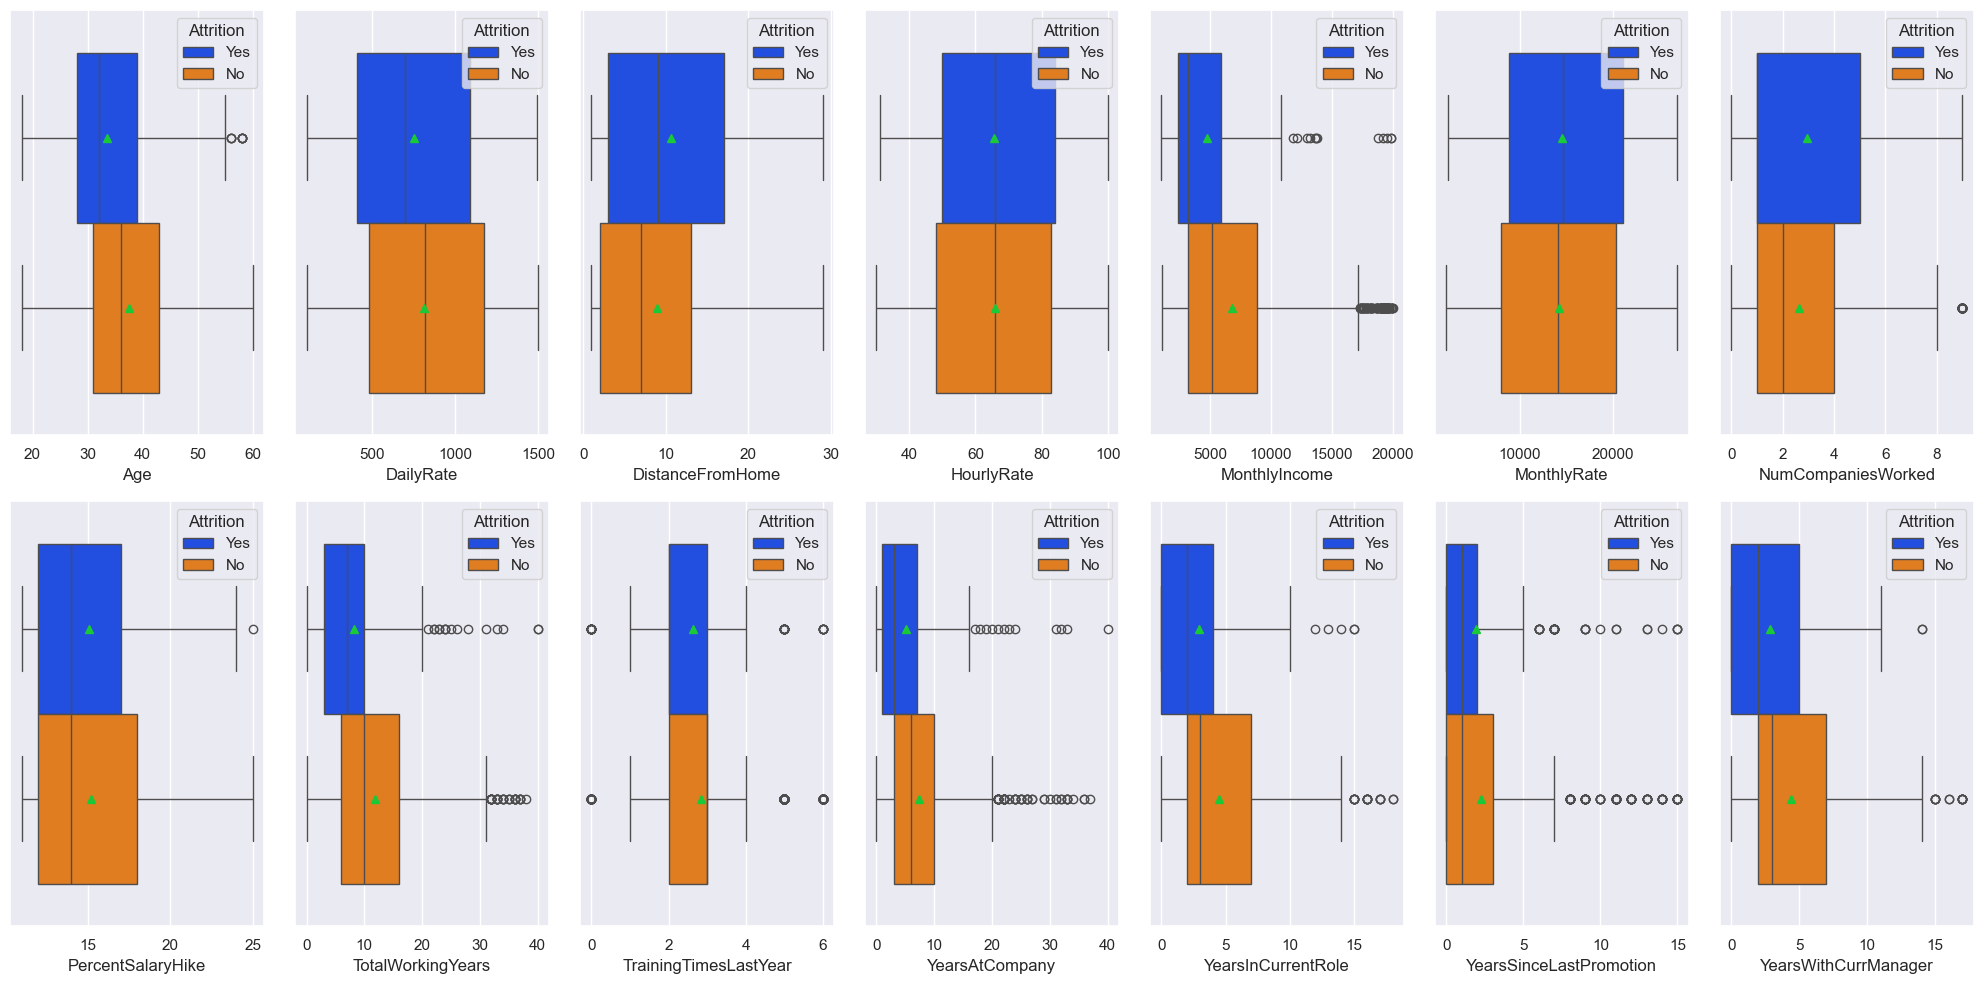

In [22]:
fig, axs = plt.subplots(2, 7, figsize=(20, 10))

for ax, coluna in zip(axs.flatten(), colunas_numericas):
    sns.boxplot(data=df, x=coluna, ax=ax, showmeans=True, hue='Attrition')

plt.tight_layout()
plt.show()

Com os boxplots, conseguimos enxergar melhor a distribuição dos valores das variáveis, olhando através da coluna alvo.

### Verificando a correlação das colunas através de um mapa de calor

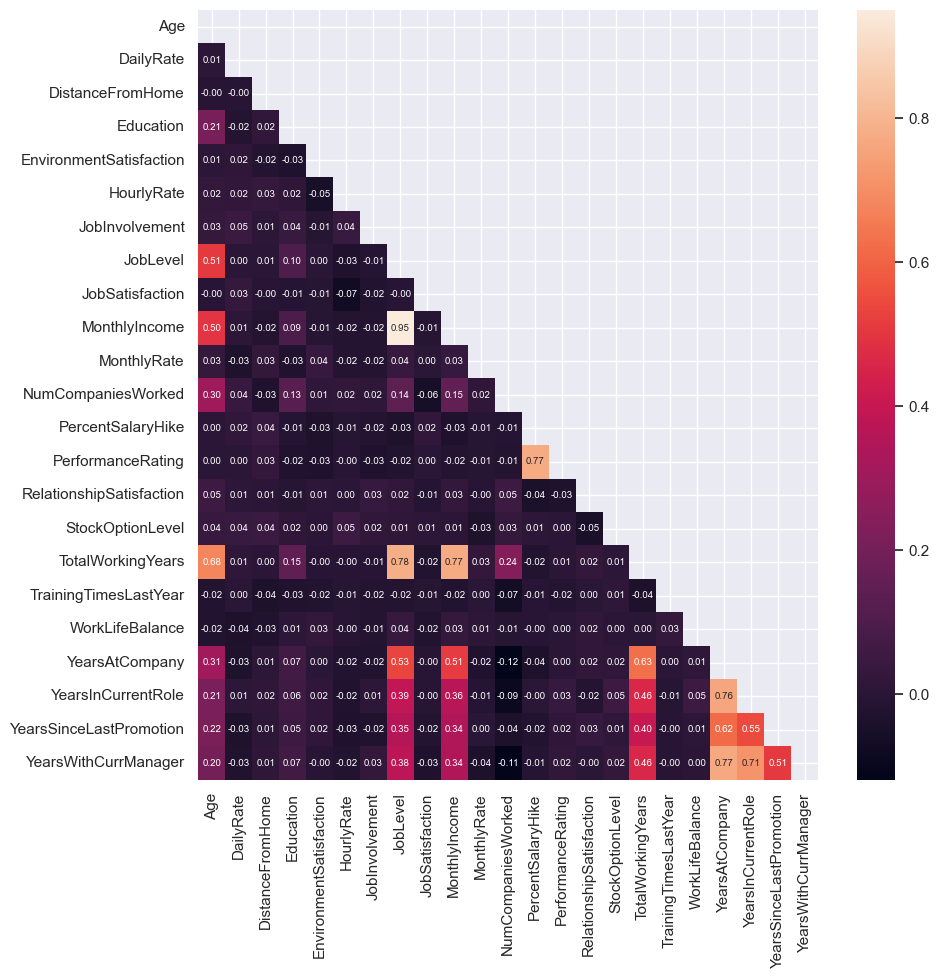

In [33]:
corr = df.select_dtypes('number').corr()
matriz = np.triu(corr)

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(corr, ax=ax, mask=matriz, annot=True, fmt='.2f', annot_kws={"fontsize": 7})

plt.show()

Com esse mapa de calor, conseguimos ver as coluunas com os maiores níveis de correlação.

### Fazendo downcast das colunas inteiras para ganhar um pouco mais de espaço

In [35]:
colunas_inteiros = [coluna for coluna in df.select_dtypes('int')]

colunas_inteiros

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [36]:
df[colunas_inteiros] = df[colunas_inteiros].apply(pd.to_numeric, downcast='integer')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int8  
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int16 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int8  
 6   Education                 1470 non-null   int8  
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int8  
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int8  
 11  JobInvolvement            1470 non-null   int8  
 12  JobLevel                  1470 non-null   int8  
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

### Exportando a base atual para ser usada na próxima etapa do projeto

In [37]:
df.to_parquet(DADOS_TRATADOS, index=False)